# Techno-Economic Assessment (TEA) PLTS Atap

Notebook ini fokus pada analisis kelayakan ekonomi PLTS Atap berbasis prediksi GHI dari model machine learning. Alurnya ringkas: komparasi model, pemilihan model terbaik, forecasting GHI 2026, transposisi POA, AEP, hingga NPV.

Skenario **METEO** dipakai sebagai basis TEA karena skenario FULL bersifat *circular* (GHI ≈ DHI + DNI·cos(θz)), sedangkan METEO hanya memakai variabel meteorologi sehingga estimasi sumber daya bersifat jujur.

## Persiapan

Memuat metrik evaluasi (`*_results.json`) dan prediksi data uji (`*_predictions.csv`) untuk LightGBM dan XGBoost sebagai dasar komparasi model.

In [15]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi visualisasi dan tampilan output
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Resolusi path agar robust terhadap working directory
candidate_dirs = [
Path("../data/processed"),
Path("ml/data/processed"),
Path("data/processed"),
]
DIR_PROCESSED = next((p for p in candidate_dirs if p.exists()), candidate_dirs[0])
DIR_RESULTS = DIR_PROCESSED.parent / "results"
DIR_MODELS = DIR_PROCESSED.parent.parent / "models"

ALGORITHMS = ["lightgbm", "xgboost"]

# Muat hasil evaluasi dan prediksi data uji untuk setiap algoritma
model_results = {}
predictions = {}
for algorithm in ALGORITHMS:
    with open(DIR_RESULTS / f"{algorithm}_results.json", encoding="utf-8") as file:
        model_results[algorithm] = json.load(file)
        df_pred = pd.read_csv(DIR_RESULTS / f"{algorithm}_predictions.csv")
        df_pred["date"] = pd.to_datetime(df_pred["date"])
        predictions[algorithm] = df_pred

# Tampilkan ringkasan hasil evaluasi yang berhasil dimuat
print("Hasil dimuat untuk:", ALGORITHMS)
for algorithm in ALGORITHMS:
    scenarios = list(model_results[algorithm]["scenarios"])
print(f"  {algorithm:9s}: skenario {scenarios} | prediksi {predictions[algorithm].shape[0]:,} baris")

Hasil dimuat untuk: ['lightgbm', 'xgboost']
  xgboost  : skenario ['METEO', 'FULL'] | prediksi 29,200 baris


## Tabel Komparasi

Rekapitulasi metrik evaluasi pada data uji 2025 untuk keempat kombinasi model (2 algoritma × 2 skenario fitur).

In [16]:
# Kumpulkan metrik evaluasi untuk setiap kombinasi algoritma dan skenario
rows = []
for algorithm in ALGORITHMS:
    for scenario, info in model_results[algorithm]["scenarios"].items():
        metrics_train = info["metrics_train"]
        metrics_test = info["metrics_test"]
        rows.append({
            "algoritma": algorithm,
            "skenario": scenario,
            "n_fitur": len(info["features"]),
            "cv_rmse": round(info["cv_rmse"], 4),
            "train_RMSE": round(metrics_train["RMSE"], 4),
            "test_RMSE": round(metrics_test["RMSE"], 4),
            "test_MAE": round(metrics_test["MAE"], 4),
            "test_R2": round(metrics_test["R2"], 4),
            "best_iter": info["best_iteration"],
        })

# Susun tabel perbandingan dan urutkan berdasarkan skenario serta Test RMSE
comparison = (
    pd.DataFrame(rows)
    .sort_values(["skenario", "test_RMSE"])
    .reset_index(drop=True)
)
comparison

,algoritma,skenario,n_fitur,cv_rmse,train_RMSE,test_RMSE,test_MAE,test_R2,best_iter
0,lightgbm,FULL,13,0.5428,0.1530,0.2147,0.1278,0.9698,812
1,xgboost,FULL,13,0.5554,0.1598,0.2583,0.1342,0.9564,1253
2,lightgbm,METEO,11,1.0790,0.9169,1.0516,0.7883,0.2765,316
3,xgboost,METEO,11,1.0849,0.9388,1.0555,0.7912,0.2712,368


## Komparasi Visual

Perbandingan metrik antar model secara visual untuk melihat perbedaan performa tiap skenario.

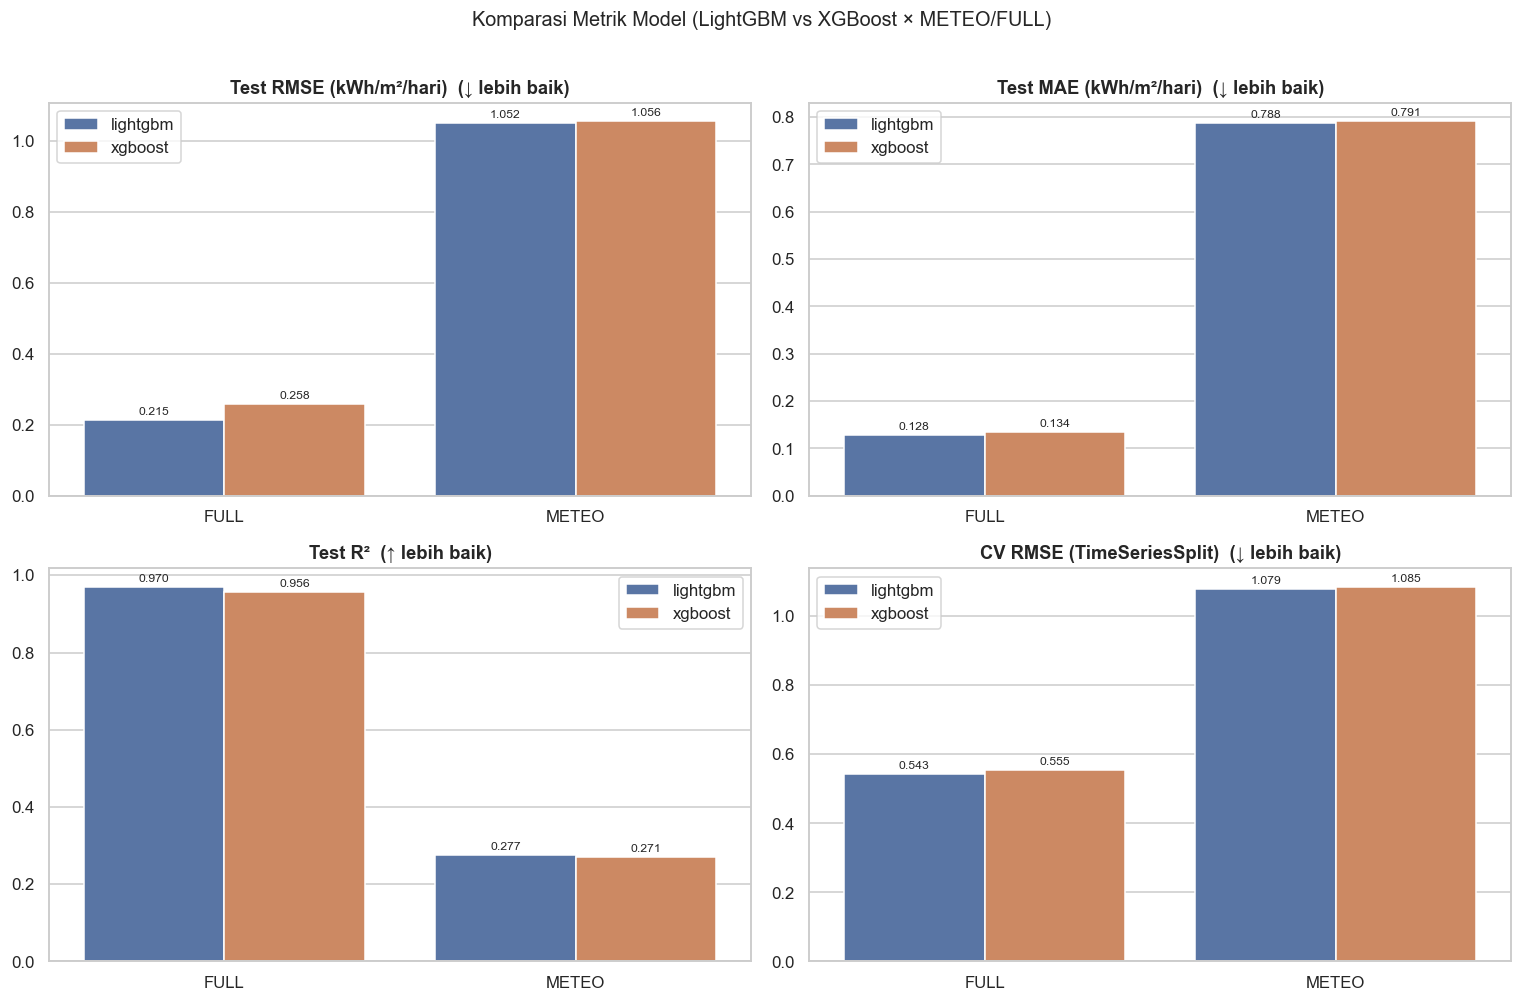

In [17]:
# Visualisasi perbandingan metrik evaluasi pada setiap skenario
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

metric_specs = [
("test_RMSE", "Test RMSE (kWh/m²/hari)", "lower"),
("test_MAE", "Test MAE (kWh/m²/hari)", "lower"),
("test_R2", "Test R²", "higher"),
("cv_rmse", "CV RMSE (TimeSeriesSplit)", "lower"),
]

for ax, (column, title, direction) in zip(axes.ravel(), metric_specs):
    sns.barplot(data=comparison, x="skenario", y=column, hue="algoritma", ax=ax)
    arrow = "↓" if direction == "lower" else "↑"
    ax.set_title(f"{title}  ({arrow} lebih baik)")
    ax.set_xlabel("")
    ax.set_ylabel("")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
        ax.legend(title="")

# Rapikan tata letak dan tampilkan seluruh visualisasi
fig.suptitle("Komparasi Metrik Model (LightGBM vs XGBoost × METEO/FULL)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Pemilihan Model Terbaik

Model terbaik ditentukan dari RMSE uji terendah pada tiap skenario. Skenario METEO dipakai sebagai basis TEA karena skenario FULL bersifat *circular*. Plot *parity* memvisualisasikan kualitas prediksi tiap model.

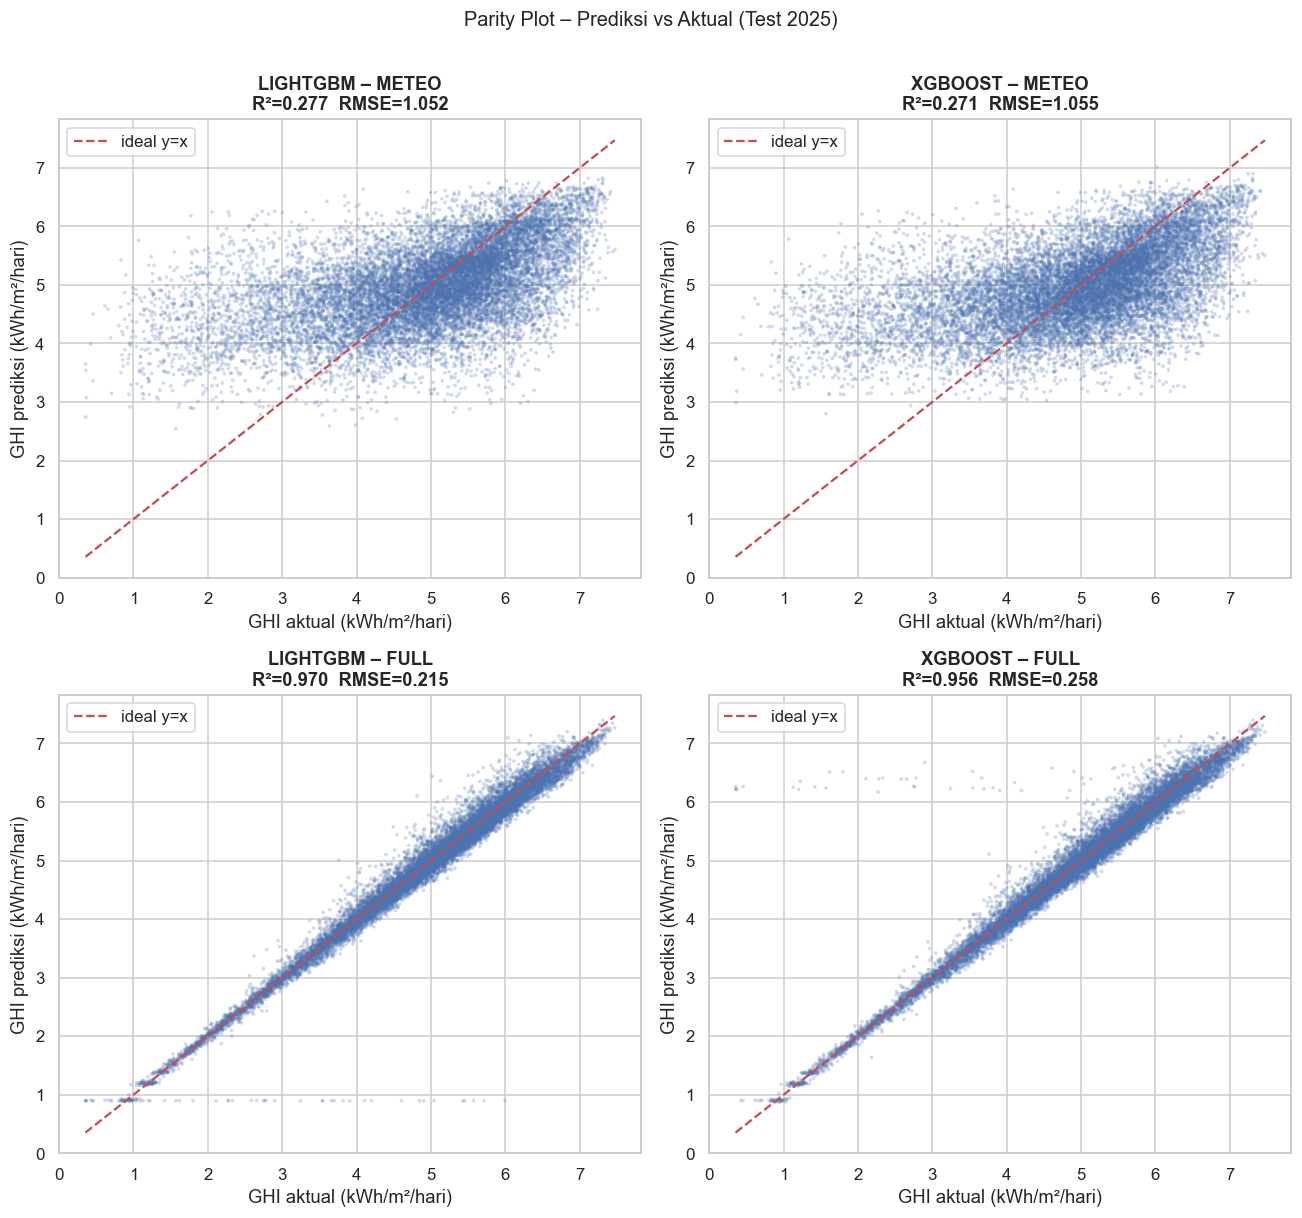

In [18]:
# Visualisasi parity plot untuk membandingkan prediksi dan nilai aktual setiap model
fig, axes = plt.subplots(2, 2, figsize=(12, 11))

model_scenarios = [
("lightgbm", "METEO"),
("xgboost", "METEO"),
("lightgbm", "FULL"),
("xgboost", "FULL"),
]

for ax, (algorithm, scenario) in zip(axes.ravel(), model_scenarios):
    data_plot = predictions[algorithm]
    data_plot = data_plot[data_plot["scenario"] == scenario]

    ax.scatter(data_plot["y_true"], data_plot["y_pred"], s=6, alpha=0.25, edgecolor="none")

    low = min(data_plot["y_true"].min(), data_plot["y_pred"].min())
    high = max(data_plot["y_true"].max(), data_plot["y_pred"].max())
    ax.plot([low, high], [low, high], "r--", lw=1.5, label="ideal y=x")

    r2 = model_results[algorithm]["scenarios"][scenario]["metrics_test"]["R2"]
    rmse = model_results[algorithm]["scenarios"][scenario]["metrics_test"]["RMSE"]
    ax.set_title(f"{algorithm.upper()} – {scenario}\nR²={r2:.3f}  RMSE={rmse:.3f}")
    ax.set_xlabel("GHI aktual (kWh/m²/hari)")
    ax.set_ylabel("GHI prediksi (kWh/m²/hari)")
    ax.legend(loc="upper left")

# Rapikan tata letak dan tampilkan parity plot
fig.suptitle("Parity Plot – Prediksi vs Aktual (Test 2025)", fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

In [19]:
# Tetapkan model terbaik pada setiap skenario berdasarkan Test RMSE terendah
best_per_scenario = {}
for scenario in ["METEO", "FULL"]:
    subset = comparison[comparison["skenario"] == scenario]
    best_per_scenario[scenario] = subset.loc[subset["test_RMSE"].idxmin(), "algoritma"]

# Tampilkan model dengan performa terbaik pada masing-masing skenario
print("Model terbaik per skenario (test RMSE terendah):")
for scenario, algorithm in best_per_scenario.items():
    print(f"  • {scenario:6s}: {algorithm.upper()}")

# Tetapkan model untuk TEA berdasarkan pemenang skenario METEO
TEA_SCENARIO = "METEO"
TEA_ALGO = best_per_scenario[TEA_SCENARIO]
print(f"\n>>> Model untuk TEA: {TEA_ALGO.upper()} - skenario {TEA_SCENARIO}")

Model terbaik per skenario (test RMSE terendah):
  • METEO : LIGHTGBM
  • FULL  : LIGHTGBM

>>> Model untuk TEA: LIGHTGBM - skenario METEO


## Parameter Input

Seluruh parameter dan asumsi TEA didefinisikan di sini. Sistem PV: 5 kWp, tilt 10° (optimal tropis), azimuth 0° (menghadap utara karena lokasi di lintang selatan). Parameter ekonomi mengikuti tarif R-1 non-subsidi.

In [20]:
# Parameter sistem photovoltaic (PV)

CAPACITY_KWP = 5.0                # Kapasitas terpasang (kWp)
TILT = 10.0                       # Sudut kemiringan modul (derajat) - optimal tropis
AZIMUTH = 0.0                     # Azimuth modul (0=utara, karena lintang selatan)
ALBEDO = 0.2                      # Albedo permukaan sekitar

# Parameter ekonomi proyek

CAPEX_PER_KWP = 15_000_000        # CAPEX per kWp (Rp)
TARIFF = 1_444.70                 # Tarif listrik (Rp/kWh, R-1 non-subsidi)
LIFETIME_YEARS = 25               # Umur proyek (tahun)
DISCOUNT_RATE = 0.06              # Discount rate riil
DEGRADATION = 0.005               # Degradasi modul per tahun (0.5%)

# Asumsi operasional dan performa sistem

PERFORMANCE_RATIO = 0.80          # Performance ratio sistem (losses)
SELF_CONSUMPTION = 0.65           # Fraksi energi yang dipakai sendiri
OPEX_RATE = 0.01                  # OPEX = 1% CAPEX per tahun
TARIFF_ESCALATION = 0.03          # Eskalasi tarif listrik per tahun

# Hitung parameter turunan berdasarkan asumsi sistem dan ekonomi

CAPEX_TOTAL = CAPACITY_KWP * CAPEX_PER_KWP
OPEX_ANNUAL = OPEX_RATE * CAPEX_TOTAL

# Tentukan koordinat lokasi target untuk analisis TEA

TARGET_LAT = -6.2
TARGET_LON = 106.8
TARGET_NAME = "Jakarta"

# Tampilkan ringkasan parameter techno-economic assessment

print("=" * 60)
print("PARAMETER TECHNO-ECONOMIC ASSESSMENT")
print("=" * 60)
print(f"Lokasi target    : {TARGET_NAME} ({TARGET_LAT}, {TARGET_LON})")
print(f"Kapasitas        : {CAPACITY_KWP} kWp")
print(f"Tilt / Azimuth   : {TILT} / {AZIMUTH} (menghadap utara)")
print(f"CAPEX total      : Rp {CAPEX_TOTAL:,.0f}")
print(f"OPEX tahunan     : Rp {OPEX_ANNUAL:,.0f}")
print(f"PR               : {PERFORMANCE_RATIO}")
print(f"Self-consumption : {SELF_CONSUMPTION}")
print(f"Degradasi        : {DEGRADATION*100:.1f}%/tahun")
print(f"Discount rate    : {DISCOUNT_RATE*100:.0f}%")

PARAMETER TECHNO-ECONOMIC ASSESSMENT
Lokasi target    : Jakarta (-6.2, 106.8)
Kapasitas        : 5.0 kWp
Tilt / Azimuth   : 10.0 / 0.0 (menghadap utara)
CAPEX total      : Rp 75,000,000
OPEX tahunan     : Rp 750,000
PR               : 0.8
Self-consumption : 0.65
Degradasi        : 0.5%/tahun
Discount rate    : 6%


## Forecasting GHI

Model METEO memerlukan variabel meteorologi (TEMP, RH, PRECIP) sebagai input. Karena nilai aktual 2026 belum tersedia, variabel tersebut dibangun melalui *climatology* berbasis *day-of-year*: rata-rata historis 2021–2025 pada grid lokasi target. Model METEO terlatih dipakai langsung untuk inferensi (tanpa retraining), sehingga bebas dari kebocoran informasi. Hasil forecast GHI 2026 inilah yang menjadi basis produksi Year-1 pada TEA.

In [21]:
import joblib

# Muat dataset fitur lengkap dan konfigurasi eksperimen
features_path = DIR_PROCESSED / "features_dataset.csv"
parquet_path = DIR_PROCESSED / "features_dataset.parquet"
if parquet_path.exists():
    df_full = pd.read_parquet(parquet_path)
else:
    df_full = pd.read_csv(features_path, parse_dates=["date"])
df_full["date"] = pd.to_datetime(df_full["date"])

with open(DIR_PROCESSED / "feature_config.json", encoding="utf-8") as file:
    feature_config = json.load(file)

METEO_FEATURES = feature_config["feature_sets"]["METEO"]
TARGET = feature_config["target"]

# Muat model terbaik pada skenario METEO untuk digunakan dalam forecasting GHI
tea_model = joblib.load(DIR_MODELS / f"{TEA_ALGO}_METEO.pkl")
print(f"Model dimuat: {TEA_ALGO}_METEO.pkl ({TEA_ALGO.upper()} - METEO)")


def parse_lat_lon(location_id):
    lat_str, lon_str = str(location_id).split("_")
    return float(lat_str), float(lon_str)


# Identifikasi grid spasial yang paling dekat dengan koordinat lokasi target
locations = (
    df_full["location_id"].drop_duplicates().to_frame()
    .assign(
        lat=lambda d: d["location_id"].map(lambda x: parse_lat_lon(x)[0]),
        lon=lambda d: d["location_id"].map(lambda x: parse_lat_lon(x)[1]),
    )
)

locations["dist"] = np.hypot(
    locations["lat"] - TARGET_LAT,
    locations["lon"] - TARGET_LON
)

nearest = locations.loc[locations["dist"].idxmin()]
TARGET_LOC_ID = nearest["location_id"]

print(
    f"Grid terdekat: {TARGET_LOC_ID} "
    f"(lat={nearest['lat']}, lon={nearest['lon']})"
)

# Ambil data historis pada grid terdekat untuk membangun pola klimatologis lokasi target
site_data = df_full[df_full["location_id"] == TARGET_LOC_ID].copy()
site_data = site_data.sort_values("date").reset_index(drop=True)
site_data["year"] = site_data["date"].dt.year

Model dimuat: lightgbm_METEO.pkl (LIGHTGBM - METEO)
Grid terdekat: -6.5000_106.5000 (lat=-6.5, lon=106.5)


In [22]:
# Tentukan variabel meteorologi, tahun forecasting, dan periode proyeksi
METEO_VARS = ["TEMP", "RH", "PRECIP"]
FORECAST_YEAR = 2026

# Bangun climatology meteorologi berdasarkan rata-rata historis untuk setiap day-of-year
clim_mean = site_data.groupby("day_of_year")[METEO_VARS].mean()

# Gunakan template fitur temporal dan spasial berdasarkan day-of-year
template = (
    site_data.sort_values("date")
    .drop_duplicates(subset="day_of_year", keep="first")
    .set_index("day_of_year", drop=False)
)

# Bentuk kalender harian untuk periode forecasting tahun 2026
future = pd.DataFrame({
    "date": pd.date_range(f"{FORECAST_YEAR}-01-01", f"{FORECAST_YEAR}-12-31", freq="D")
})
future["doy"] = future["date"].dt.dayofyear
future["day_of_year"] = future["doy"]

# Isi fitur temporal dan spasial menggunakan template berdasarkan day-of-year
for col in METEO_FEATURES:
    if col in METEO_VARS:
        continue
    future[col] = future["doy"].map(template[col])

# Isi variabel meteorologi 2026 menggunakan nilai climatology historis per day-of-year
for var in METEO_VARS:
    future[var] = future["doy"].map(clim_mean[var])

# Lakukan forecasting GHI 2026 menggunakan model METEO tanpa proses retraining
future["GHI_pred"] = np.clip(
    tea_model.predict(future[METEO_FEATURES]),
    0,
    None
)

GHI_2026_annual = float(future["GHI_pred"].sum())

print("=" * 60)
print(f"FORECAST GHI {FORECAST_YEAR} (climatology-based, {TEA_ALGO.upper()} - METEO)")
print("=" * 60)
print(f"  Jumlah hari       : {len(future)}")
print(f"  GHI harian (mean) : {future['GHI_pred'].mean():.3f} kWh/m2/hari")
print(f"  GHI tahunan       : {GHI_2026_annual:,.1f} kWh/m2/thn")

FORECAST GHI 2026 (climatology-based, LIGHTGBM - METEO)
  Jumlah hari       : 365
  GHI harian (mean) : 4.550 kWh/m2/hari
  GHI tahunan       : 1,660.9 kWh/m2/thn


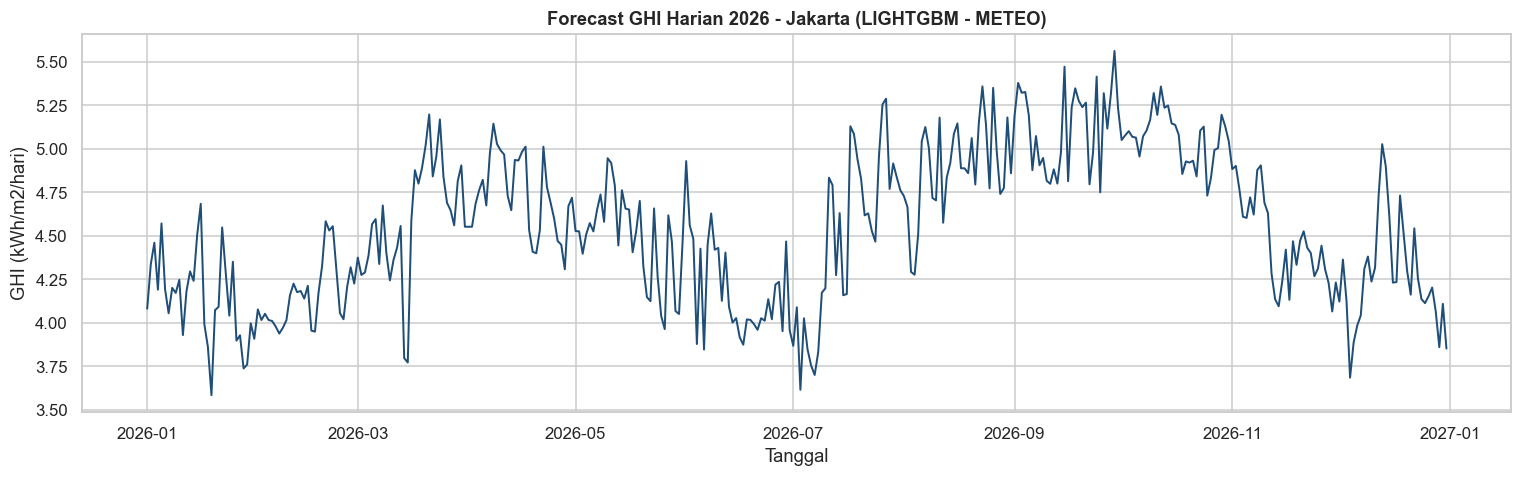

In [23]:
# Visualisasi forecast GHI harian 2026
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(future["date"], future["GHI_pred"], color="#1f4e79", lw=1.3)
ax.set_title(f"Forecast GHI Harian {FORECAST_YEAR} - {TARGET_NAME} ({TEA_ALGO.upper()} - METEO)")
ax.set_xlabel("Tanggal")
ax.set_ylabel("GHI (kWh/m2/hari)")
plt.tight_layout()
plt.show()

## POA

GHI horizontal tidak langsung dikonversi ke energi. Radiasi ditransposisikan ke bidang modul (*Plane-of-Array*) melalui pipeline standar: posisi matahari (NREL SPA) → dekomposisi GHI menjadi DNI/DHI (Erbs, 1982) → transposisi ke bidang modul (Perez, 1990). Tahap ini penting karena modul yang dimiringkan menerima radiasi berbeda dari bidang horizontal.

In [24]:
import pvlib
from pvlib.location import Location

# Menghitung irradiance pada bidang modul (POA) dan estimasi AEP berdasarkan forecast GHI harian
def calculate_annual_poa_and_aep(daily_ghi, dates, latitude, longitude,
                                 tilt, azimuth, albedo, capacity_kwp, pr):
    # Pipeline perhitungan: solar position -> dekomposisi Erbs -> transposisi Perez -> POA -> AEP
    site = Location(latitude, longitude, tz="Asia/Jakarta")

    results_poa, results_dni, results_dhi = [], [], []
    for date, ghi_kwh in zip(dates, daily_ghi):
        noon = pd.Timestamp(date).replace(hour=12, minute=0)
        times = pd.DatetimeIndex([noon], tz="Asia/Jakarta")

        solpos = site.get_solarposition(times)
        zenith = solpos["apparent_zenith"].iloc[0]
        sol_azimuth = solpos["azimuth"].iloc[0]

        if zenith >= 90:
            results_poa.append(0.0)
            results_dni.append(0.0)
            results_dhi.append(0.0)
            continue

        doy = pd.Timestamp(date).dayofyear
        dni_extra = pvlib.irradiance.get_extra_radiation(doy)
        cos_zenith = np.cos(np.radians(zenith))

        # Konversi GHI harian menjadi irradiance rata-rata siang dan hitung clearness index
        if cos_zenith > 0.05 and dni_extra > 0:
            ghi_wm2 = ghi_kwh * 1000 / 10.0
            kt = np.clip(ghi_wm2 / (dni_extra * cos_zenith), 0, 1.0)
        else:
            kt = 0.0
            ghi_wm2 = 0.0

        # Dekomposisi Erbs untuk memperoleh komponen DHI dan DNI dari GHI
        if kt > 0 and ghi_wm2 > 0:
            if kt <= 0.22:
                kd = 1.0 - 0.09 * kt
            elif kt <= 0.80:
                kd = (0.9511 - 0.1604*kt + 4.388*kt**2
                      - 16.638*kt**3 + 12.336*kt**4)
            else:
                kd = 0.165
            dhi_wm2 = kd * ghi_wm2
            dni_wm2 = max((ghi_wm2 - dhi_wm2) / max(cos_zenith, 0.05), 0)
        else:
            dhi_wm2 = 0.0
            dni_wm2 = 0.0

        # Transposisi irradiance dari bidang horizontal ke bidang modul menggunakan model Perez
        try:
            poa = pvlib.irradiance.get_total_irradiance(
                surface_tilt=tilt, surface_azimuth=azimuth,
                solar_zenith=zenith, solar_azimuth=sol_azimuth,
                dni=dni_wm2, ghi=ghi_wm2, dhi=dhi_wm2,
                dni_extra=dni_extra, model="perez", albedo=albedo,
            )
            poa_val = poa["poa_global"]
            poa_wm2 = float(poa_val.iloc[0]) if hasattr(poa_val, "iloc") else float(poa_val)
            poa_wm2 = max(poa_wm2, 0)
        except Exception:
            poa_wm2 = ghi_wm2

        results_poa.append(poa_wm2 * 10.0 / 1000.0)
        results_dni.append(dni_wm2 * 10.0 / 1000.0)
        results_dhi.append(dhi_wm2 * 10.0 / 1000.0)

    poa_daily = np.array(results_poa)
    return {
        "poa_daily": poa_daily,
        "poa_annual": poa_daily.sum(),
        "aep_kwh": capacity_kwp * poa_daily.sum() * pr,
        "dni_daily": np.array(results_dni),
        "dhi_daily": np.array(results_dhi),
    }


# Hitung POA dan AEP tahun pertama berdasarkan forecast GHI 2026
res_2026 = calculate_annual_poa_and_aep(
    daily_ghi=future["GHI_pred"].values,
    dates=future["date"].values,
    latitude=nearest["lat"],
    longitude=nearest["lon"],
    tilt=TILT,
    azimuth=AZIMUTH,
    albedo=ALBEDO,
    capacity_kwp=CAPACITY_KWP,
    pr=PERFORMANCE_RATIO,
)

POA_YEAR1 = res_2026["poa_annual"]

print(f"GHI tahunan {FORECAST_YEAR}      : {GHI_2026_annual:,.1f} kWh/m2/thn")
print(f"POA tahunan {FORECAST_YEAR}      : {POA_YEAR1:,.1f} kWh/m2/thn")
print(f"Gain transposisi POA/GHI : {POA_YEAR1 / GHI_2026_annual - 1:+.1%}")

GHI tahunan 2026      : 1,660.9 kWh/m2/thn
POA tahunan 2026      : 1,660.7 kWh/m2/thn
Gain transposisi POA/GHI : -0.0%


## AEP

*Annual Energy Production* (Year-1) dihitung dari total POA tahunan dikali kapasitas terpasang dan *performance ratio*: AEP = kapasitas × POA × PR. Nilai ini menjadi basis produksi tahun pertama pada analisis finansial.

In [25]:
# Hitung produksi energi tahunan dan specific yield sistem PV
E_YEAR1 = res_2026["aep_kwh"]
SPECIFIC_YIELD = E_YEAR1 / CAPACITY_KWP

# Tampilkan ringkasan hasil produksi energi tahun pertama
print("=" * 60)
print(f"ANNUAL ENERGY PRODUCTION (Year-1 = forecast {FORECAST_YEAR})")
print("=" * 60)
print(f" POA tahunan       : {POA_YEAR1:,.1f} kWh/m2/thn")
print(f" Performance ratio : {PERFORMANCE_RATIO}")
print(f" AEP Year-1        : {E_YEAR1:,.0f} kWh")
print(f" Specific yield    : {SPECIFIC_YIELD:,.0f} kWh/kWp/thn")

ANNUAL ENERGY PRODUCTION (Year-1 = forecast 2026)
 POA tahunan       : 1,660.7 kWh/m2/thn
 Performance ratio : 0.8
 AEP Year-1        : 6,643 kWh
 Specific yield    : 1,329 kWh/kWp/thn


## NPV

Kelayakan proyek dinilai dari *Net Present Value* selama umur ekonomis 25 tahun. Arus kas tiap tahun memperhitungkan degradasi modul, fraksi *self-consumption*, tarif tereskalasi, dan OPEX. Proyek dinilai **layak** apabila NPV > 0.

Arus kas tahun ke-n: CF(n) = AEP × (1−d)^(n−1) × f_self × Tarif(n) − OPEX.

In [26]:
def npv(rate, cashflows):
    # Menghitung Net Present Value (NPV) berdasarkan arus kas setiap tahun
    # cashflows[0] merupakan arus kas tahun ke-0, yaitu investasi awal (CAPEX)
    cf = np.asarray(cashflows, dtype=float)
    t = np.arange(len(cf))
    return np.sum(cf / (1 + rate) ** t)


# Membentuk profil produksi energi selama umur proyek dengan memperhitungkan degradasi modul
years = np.arange(1, LIFETIME_YEARS + 1)
energy_per_year = E_YEAR1 * (1 - DEGRADATION) ** (years - 1)
energy_used = energy_per_year * SELF_CONSUMPTION
tariff_per_year = TARIFF * (1 + TARIFF_ESCALATION) ** (years - 1)
savings_per_year = energy_used * tariff_per_year

# Menyusun arus kas proyek dan menghitung NPV berdasarkan discount rate
net_cashflow_annual = savings_per_year - OPEX_ANNUAL
cashflows = np.concatenate([[-CAPEX_TOTAL], net_cashflow_annual])
project_npv = npv(DISCOUNT_RATE, cashflows)

# Menampilkan indikator produksi energi dan kelayakan finansial proyek
print("=" * 60)
print("INDIKATOR KELAYAKAN FINANSIAL (fokus AEP & NPV)")
print("=" * 60)
print(f"AEP Year-1        : {E_YEAR1:,.0f} kWh (forecast {FORECAST_YEAR})")
print(f"Specific yield    : {SPECIFIC_YIELD:,.0f} kWh/kWp/thn")
print(f"Total energi 25y  : {energy_per_year.sum():,.0f} kWh")
print(f"Total penghematan : Rp {savings_per_year.sum():,.0f}")
print(f"NPV (r={DISCOUNT_RATE:.0%})        : Rp {project_npv:,.0f}")
print(f"Status kelayakan  : {'LAYAK' if project_npv > 0 else 'TIDAK LAYAK'}")

INDIKATOR KELAYAKAN FINANSIAL (fokus AEP & NPV)
AEP Year-1        : 6,643 kWh (forecast 2026)
Specific yield    : 1,329 kWh/kWp/thn
Total energi 25y  : 156,475 kWh
Total penghematan : Rp 212,657,655
NPV (r=6%)        : Rp 16,497,858
Status kelayakan  : LAYAK


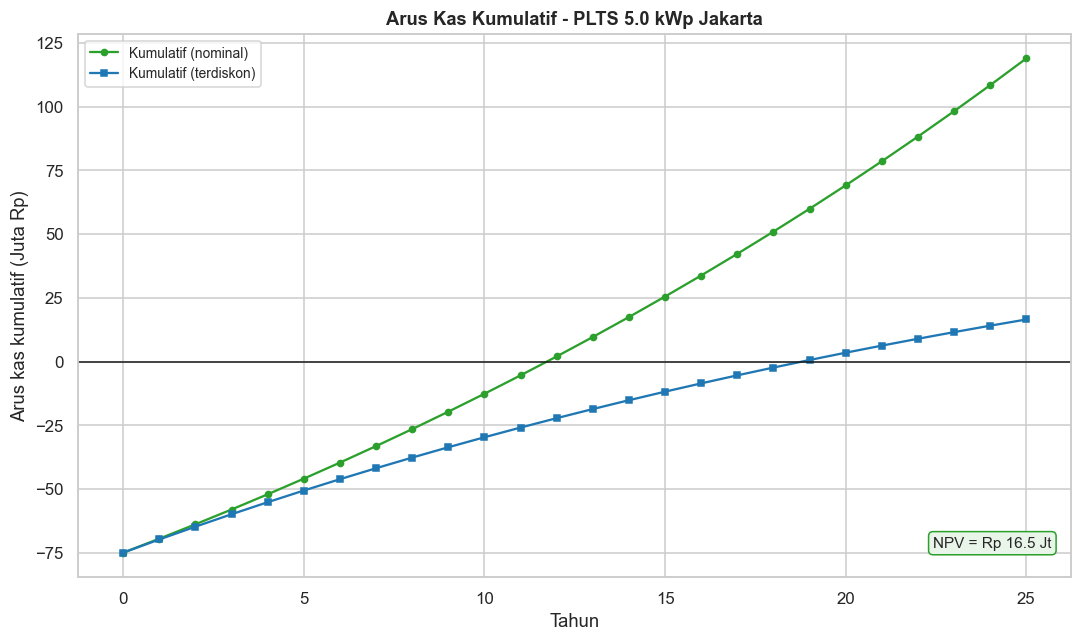

In [27]:
# Hitung faktor diskonto dan arus kas setelah memperhitungkan nilai waktu uang
discount_factor = 1 / (1 + DISCOUNT_RATE) ** years
discounted_cashflows = np.concatenate([[-CAPEX_TOTAL], net_cashflow_annual * discount_factor])

# Hitung arus kas kumulatif nominal dan terdiskon untuk melihat perkembangan investasi
year_axis = np.arange(0, LIFETIME_YEARS + 1)
cumulative_nominal = np.cumsum(cashflows)
cumulative_discounted = np.cumsum(discounted_cashflows)

# Visualisasikan perkembangan arus kas kumulatif selama umur proyek
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(year_axis, cumulative_nominal / 1e6, "o-", label="Kumulatif (nominal)", color="#2ca02c", markersize=4)
ax.plot(year_axis, cumulative_discounted / 1e6, "s-", label="Kumulatif (terdiskon)", color="#1f77b4", markersize=4)
ax.axhline(0, color="k", lw=1)
ax.text(0.98, 0.05, f"NPV = Rp {project_npv/1e6:,.1f} Jt",
transform=ax.transAxes, ha="right", va="bottom", fontsize=10,
bbox=dict(boxstyle="round", fc="#eaf5ea", ec="#2ca02c"))
ax.set_title(f"Arus Kas Kumulatif - PLTS {CAPACITY_KWP} kWp {TARGET_NAME}")
ax.set_xlabel("Tahun")
ax.set_ylabel("Arus kas kumulatif (Juta Rp)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()